In [3]:
import cv2 as cv
import matplotlib.pyplot as plt
!pip install opencv-python

Câu 1

Found 5 face(s)


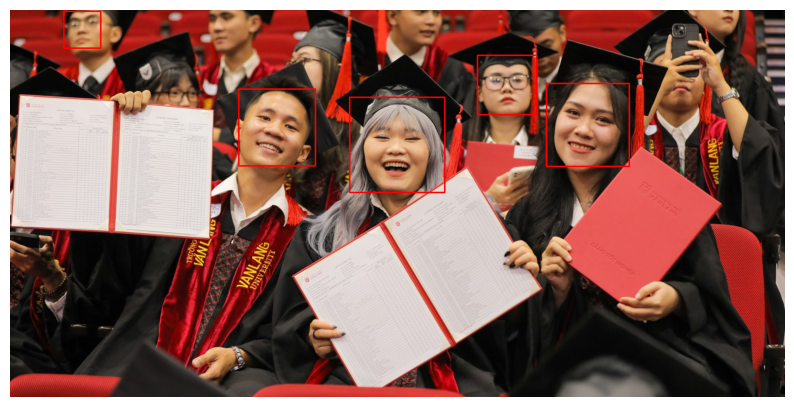

In [6]:
import cv2
import matplotlib.pyplot as plt
import os

# Path to the image and the face cascade file
img_path = "/content/image2.jpg"
cascade_path = "/content/haarcascade_frontalface_default.xml"

if os.path.exists(img_path) and os.path.exists(cascade_path):
    # Load image
    img = cv2.imread(img_path)
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Load the Haar Cascade for face detection
    face_cascade = cv2.CascadeClassifier(cascade_path)

    # Detect faces
    faces = face_cascade.detectMultiScale(img_gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

    print(f"Found {len(faces)} face(s)")

    # Draw rectangles around faces
    for (x, y, w, h) in faces:
        cv2.rectangle(img_rgb, (x, y), (x + w, y + h), (255, 0, 0), 2)

    # Display the result
    plt.figure(figsize=(10, 6))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()
else:
    print("Error: Ensure both image.jpg and haarcascade_frontalface_default.xml exist in /content/")

Câu 2

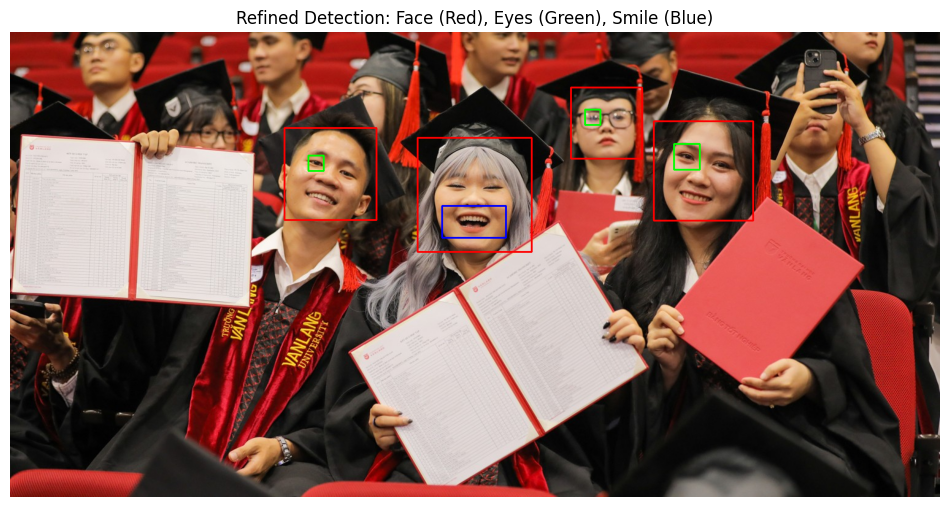

In [11]:
import cv2
import matplotlib.pyplot as plt
import os

img_path = "/content/image2.jpg"
face_cascade = cv2.CascadeClassifier("/content/haarcascade_frontalface_default.xml")
eye_cascade = cv2.CascadeClassifier("/content/haarcascade_eye.xml")
smile_cascade = cv2.CascadeClassifier("/content/haarcascade_smile.xml")

if os.path.exists(img_path):
    img = cv2.imread(img_path)
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Nhận diện khuôn mặt với tham số khắt khe hơn để tránh nhầm lẫn
    faces = face_cascade.detectMultiScale(img_gray, scaleFactor=1.1, minNeighbors=6, minSize=(50, 50))

    for (x, y, w, h) in faces:
        cv2.rectangle(img_rgb, (x, y), (x + w, y + h), (255, 0, 0), 2)

        roi_gray = img_gray[y:y+h, x:x+w]
        roi_color = img_rgb[y:y+h, x:x+w]

        # Giới hạn tìm mắt ở nửa trên khuôn mặt để tránh nhận diện nhầm mũi/miệng
        eye_roi_gray = roi_gray[0:int(h/1.8), 0:w]
        eye_roi_color = roi_color[0:int(h/1.8), 0:w]

        eyes = eye_cascade.detectMultiScale(eye_roi_gray, scaleFactor=1.1, minNeighbors=10)
        for (ex, ey, ew, eh) in eyes:
            cv2.rectangle(eye_roi_color, (ex, ey), (ex + ew, ey + eh), (0, 255, 0), 2)

        # Nhận diện nụ cười ở nửa dưới khuôn mặt
        smile_roi_gray = roi_gray[int(h/1.8):h, 0:w]
        smile_roi_color = roi_color[int(h/1.8):h, 0:w]

        smiles = smile_cascade.detectMultiScale(smile_roi_gray, scaleFactor=1.7, minNeighbors=22)
        for (sx, sy, sw, sh) in smiles:
            cv2.rectangle(smile_roi_color, (sx, sy), (sx + sw, sy + sh), (0, 0, 255), 2)

    plt.figure(figsize=(12, 8))
    plt.imshow(img_rgb)
    plt.title("Refined Detection: Face (Red), Eyes (Green), Smile (Blue)")
    plt.axis('off')
    plt.show()
else:
    print(f"File not found: {img_path}")